### This jupyter notebook contains contents of the lesson "Linear models in non-linear datasets"

**Author : Umidjon Sattorov. Machine Learning engineer**

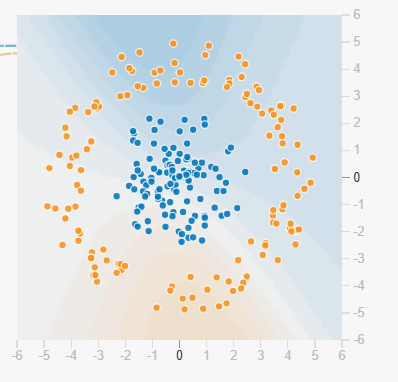

In [9]:
# Importing necessary libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

np.random.seed(0)

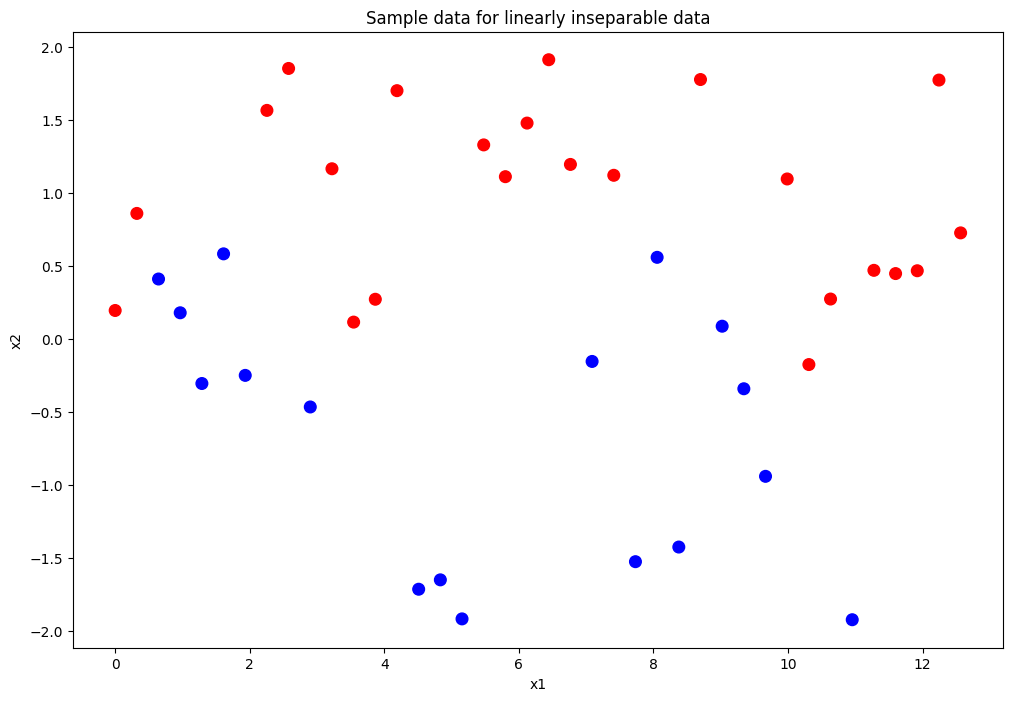

In [10]:
# Generating x1 and x2 features
x1 = np.linspace(0, 4*np.pi, 40)
x2 = np.random.uniform(-2, 2, size = 40)
labels = (x2 > np.sin(x1)).astype(int)

df_sample = pd.DataFrame({"x1": x1, "x2": x2, "label": labels})

# Plotting visualization
plt.figure(figsize = (12, 8))
plt.scatter(df_sample['x1'], df_sample['x2'], c = df_sample["label"], cmap = 'bwr', s = 70)
plt.title("Sample data for linearly inseparable data")
plt.xlabel(xlabel = "x1")
plt.ylabel(ylabel = "x2")
plt.show() 

In [11]:
# Trying to solve the problem using linear regression function
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# Dividing data into X and y parts
x = df_sample[['x1', 'x2']]
y = df_sample['label']

# Training and drawing decision boundary of the model
lr = LogisticRegression(random_state = 42)
lr.fit(X = x, y = y)
pred_y = lr.predict(X = x)

# Model evaluation part
print(f"Accuracy score of the Logistic regression model :{accuracy_score(y_true = y, y_pred = pred_y)}")

Accuracy score of the Logistic regression model :0.85


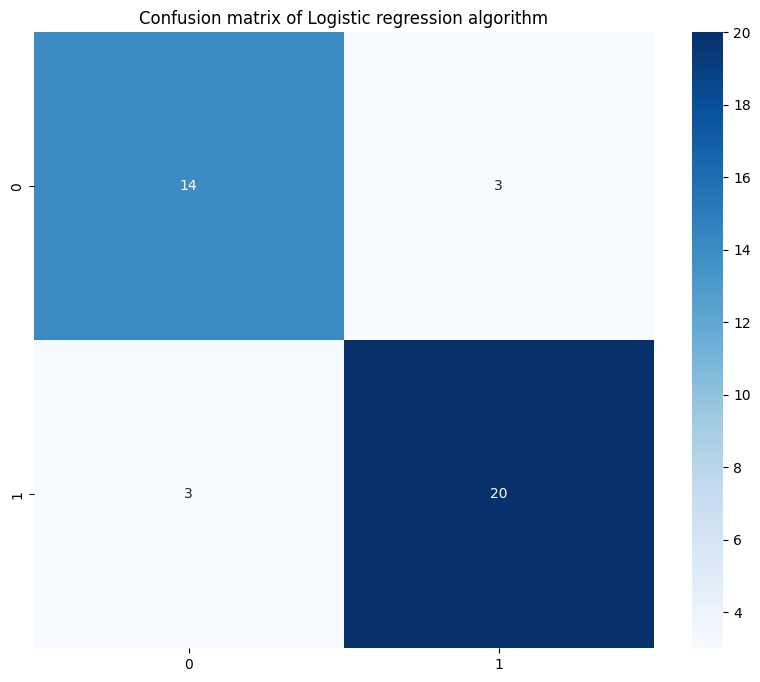

In [12]:
# Drawing confusion matrix of the model
import seaborn as sns

cm = confusion_matrix(y_true = y, y_pred = pred_y)

plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = True, xticklabels = lr.classes_, yticklabels = lr.classes_)
plt.title("Confusion matrix of Logistic regression algorithm")
plt.show()

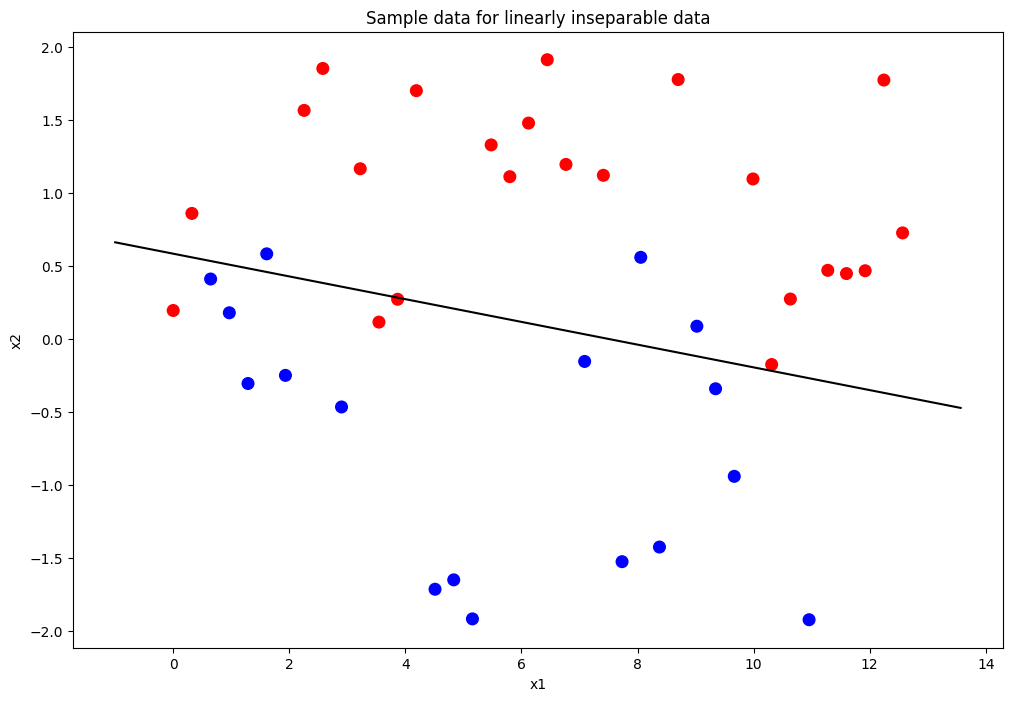

In [13]:
# Plotting decision boundary
w1 = lr.coef_[0][0]
w2 = lr.coef_[0][1]
b  = lr.intercept_[0]
x_values = np.linspace(df_sample['x1'].min()-1, df_sample['x1'].max()+1, 100)
y_values = -(w1/w2) * x_values - (b/w2)


# Plotting visualization
plt.figure(figsize = (12, 8))
plt.scatter(df_sample['x1'], df_sample['x2'], c = df_sample["label"], cmap = 'bwr', s = 70)
plt.plot(x_values, y_values, 'k-', label="Decision boundary of Logistic Regression")
plt.title("Sample data for linearly inseparable data")
plt.xlabel(xlabel = "x1")
plt.ylabel(ylabel = "x2")
plt.show() 

In [14]:
# Implementation of sinusoidal function to the result of the linear regression
x.loc[:,'x1'] = np.sin(x['x1'])

# Training and drawing decision boundary of the model
lr = LogisticRegression(random_state = 42)
lr.fit(X = x, y = y)
pred_y = lr.predict(X = x)

# Model evaluation part
print(f"Accuracy score of the Logistic regression model :{accuracy_score(y_true = y, y_pred = pred_y)}")

Accuracy score of the Logistic regression model :1.0


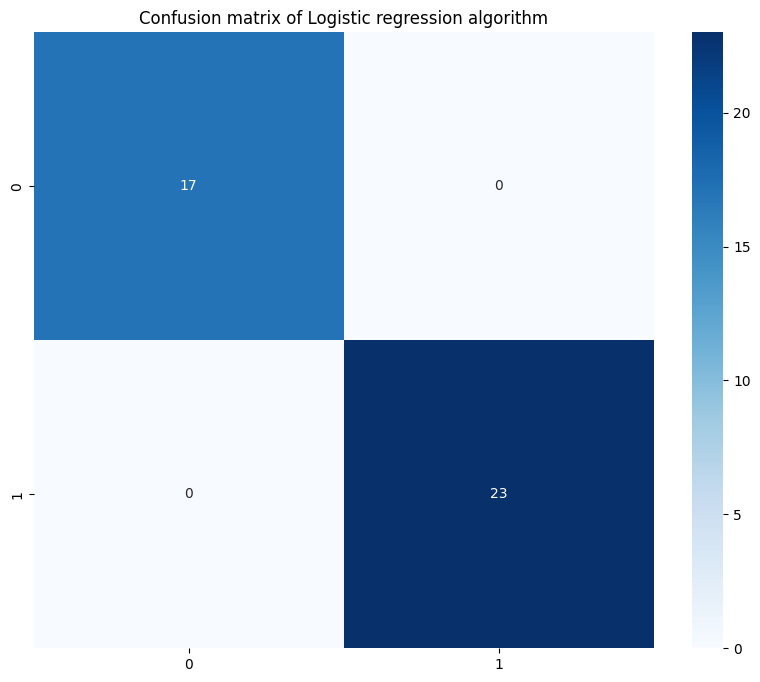

In [15]:
# Checking visualization of the new feature add
cm = confusion_matrix(y_true = y, y_pred = pred_y)

plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = True, xticklabels = lr.classes_, yticklabels = lr.classes_)
plt.title("Confusion matrix of Logistic regression algorithm")
plt.show()

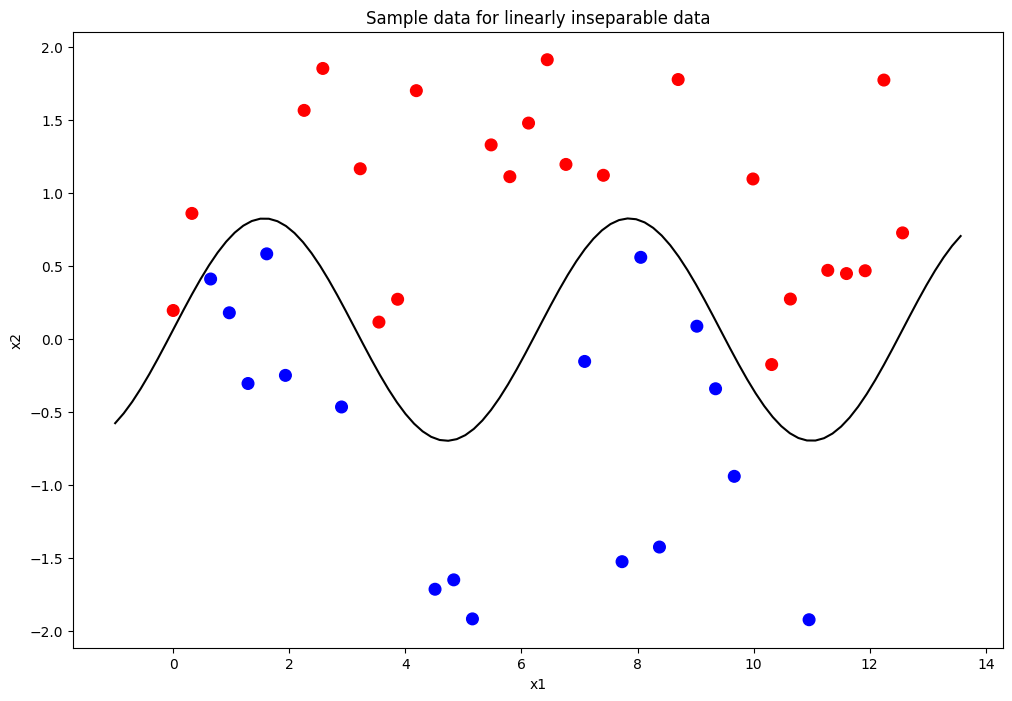

In [16]:
# Plotting decision boundary
w1 = lr.coef_[0][0]
w2 = lr.coef_[0][1]
b  = lr.intercept_[0]
x_values = np.linspace(df_sample['x1'].min()-1, df_sample['x1'].max()+1, 100)
y_values = -(w1/w2) * np.sin(x_values) - (b/w2)


# Plotting visualization
plt.figure(figsize = (12, 8))
plt.scatter(df_sample['x1'], df_sample['x2'], c = df_sample["label"], cmap = 'bwr', s = 70)
plt.plot(x_values, y_values, 'k-', label="Decision boundary of Logistic Regression")
plt.title("Sample data for linearly inseparable data")
plt.xlabel(xlabel = "x1")
plt.ylabel(ylabel = "x2")
plt.show() 

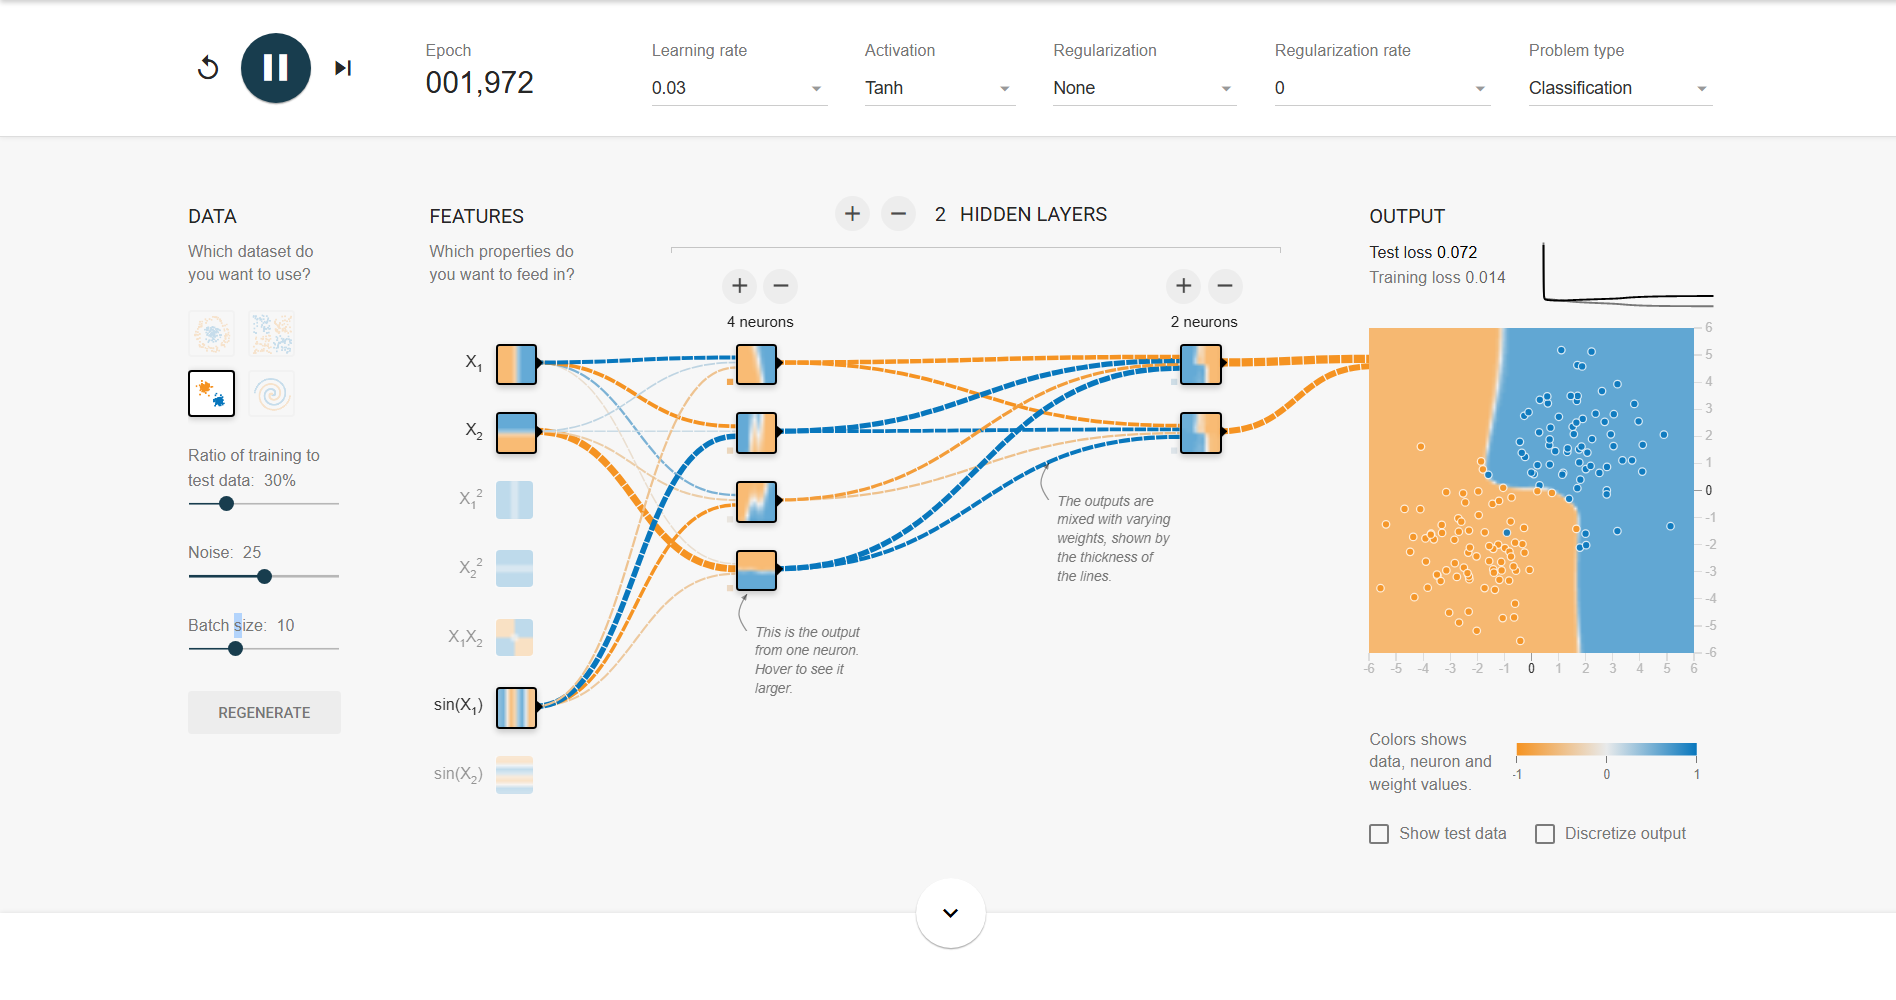

#### Tasks :

1) Check if the neural network can solve the classification task of the dataset below better when it uses sinusoidal function or x**2 polynomial functions.

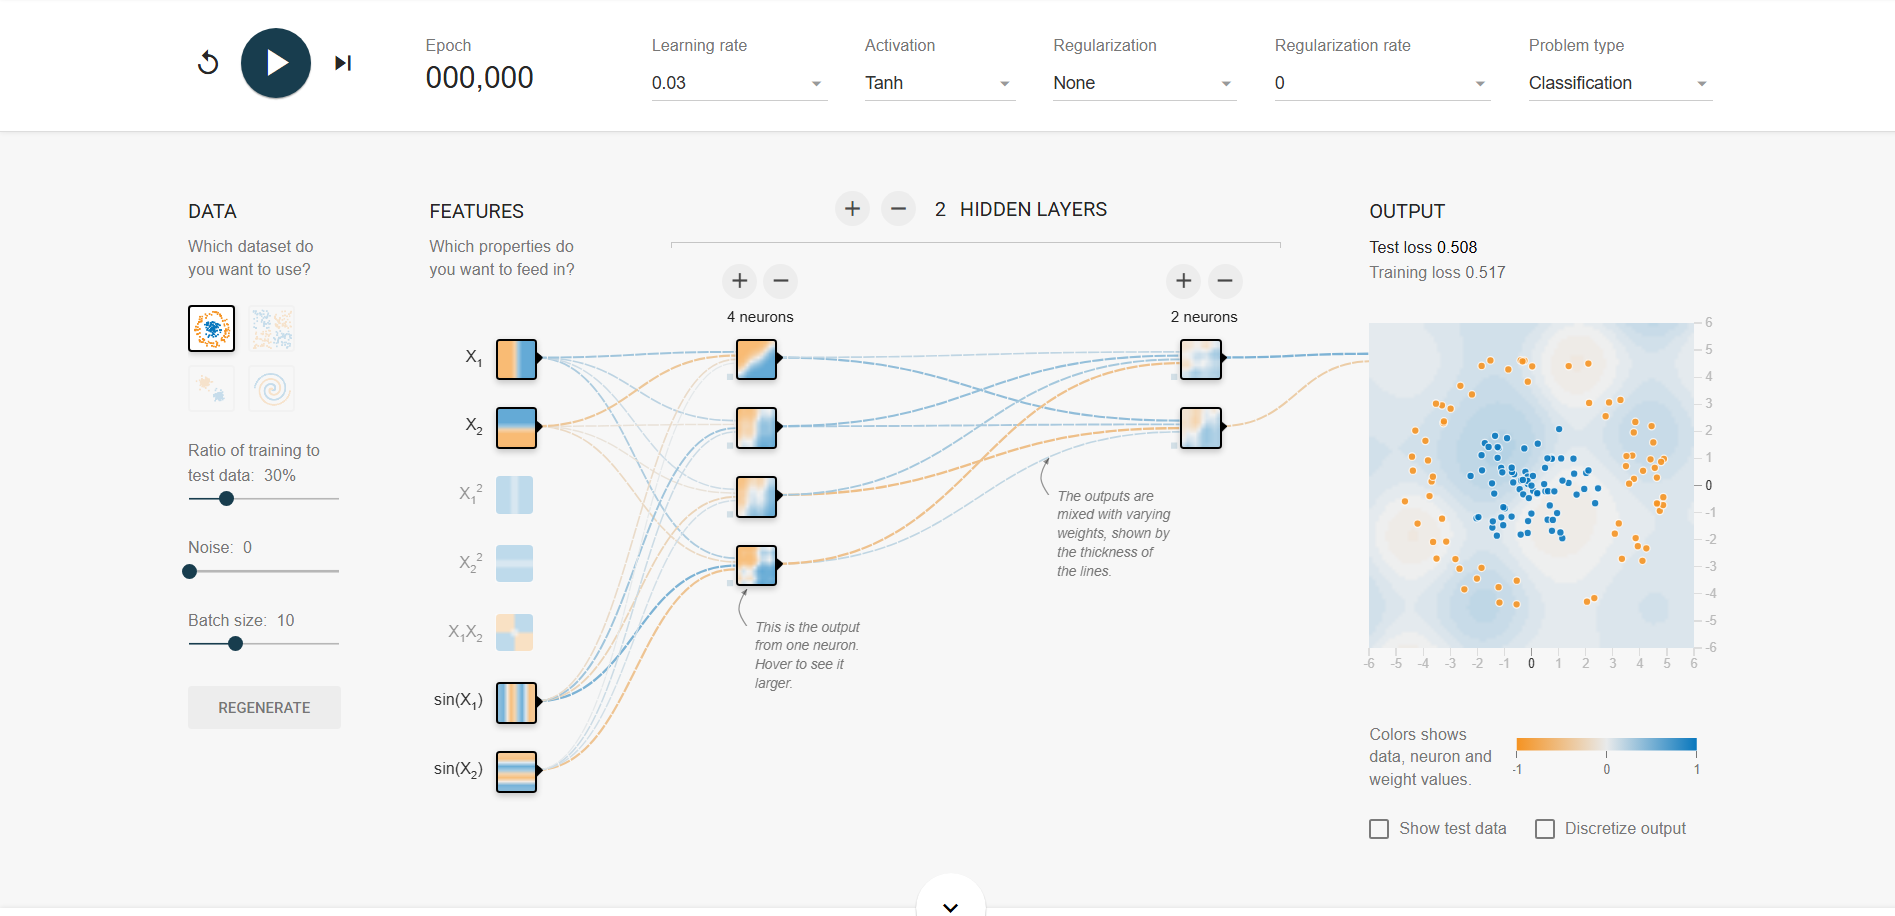

____

### Gradient decent in regression and classification problems

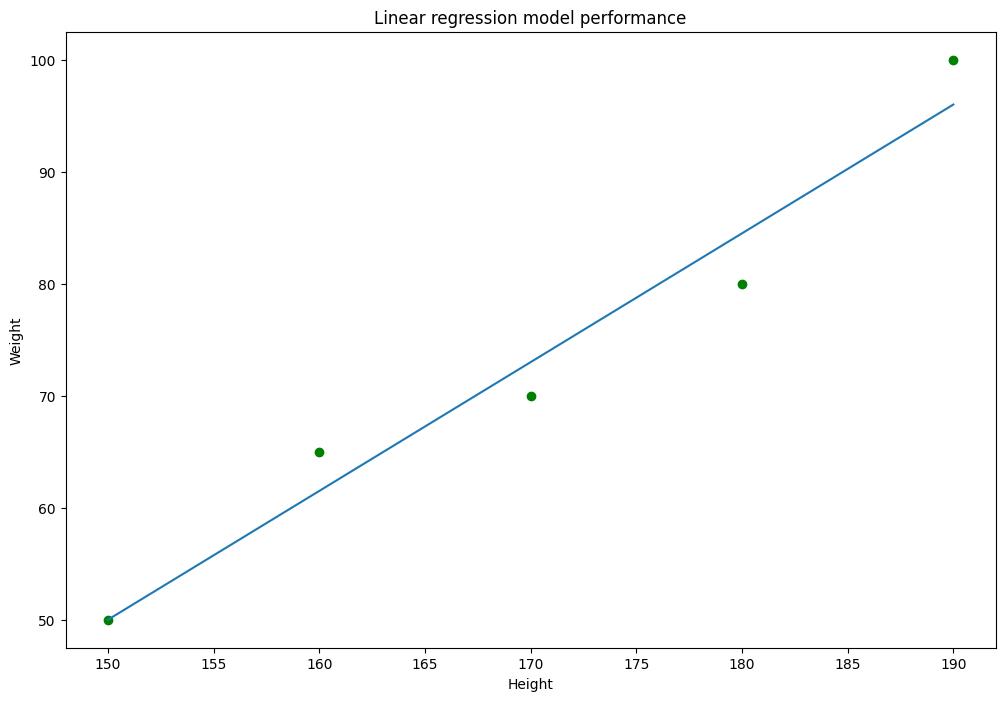

In [17]:
# Linear regression gradient decent
from sklearn.linear_model import LinearRegression

df = pd.DataFrame(
    {
        'Height' : [150, 160, 170, 180, 190],
        'Weight' : [50, 65, 70, 80, 100]
    }
)

lr = LinearRegression()
lr.fit(X = df[['Height']], y = df['Weight'])
results = lr.predict(X = df[['Height']])

# Visualizing data in scatterplot
plt.figure(figsize = (12, 8))
plt.title(label = "Linear regression model performance")
plt.scatter(x = df['Height'], y = df['Weight'], c = 'green')
plt.plot(df['Height'], results)
plt.xlabel(xlabel = 'Height')
plt.ylabel(ylabel = "Weight")
plt.show()

In [18]:
from sklearn.metrics import mean_squared_error

mse_lr = mean_squared_error(y_true = df['Weight'], y_pred = results)
mse_lr

11.5

In [ ]:
# Visualization of the mean squared error
import plotly.graph_objects as go
from ipywidgets import interact


# Function that updates the MSE plot
def plot_mse(w0 = 0, w1 = 0.5):
    # Range of w1 values for the curve
    w1_range = np.linspace(-1, 2, 200)
    
    # Compute MSE for all w1 in the range (keeping w0 fixed)
    mse_values = [np.mean([(w0 + w*h - y)**2 for h, y in zip(df['Height'], df['Weight'])]) for w in w1_range]
    
    # Current MSE for chosen w1
    mse_current = np.mean([(w0 + w1*h - y)**2 for h, y in zip(df['Height'], df['Weight'])])
    
    fig = go.Figure()
    
    # Plot the MSE curve
    fig.add_trace(go.Scatter(
        x = w1_range, y = mse_values,
        mode = 'lines',
        name = 'MSE curve',
        line = dict(color='blue')
    ))
    
    # Add moving point for current w1
    fig.add_trace(go.Scatter(
        x = [w1], y = [mse_current],
        mode='markers+text',
        text=[f"MSE={mse_current:.2f}"],
        textposition="top center",
        marker=dict(size=12, color='red'),
        name='Current MSE'
    ))
    
    fig.update_layout(
        title=f"MSE as function of w1 (w0={w0})",
        xaxis_title="w1",
        yaxis_title="Mean Squared Error",
        width=700,
        height=500
    )
    
    fig.show()

# Interactive sliders
interact(plot_mse, w0=(-100, 100, 10), w1=(-1.0, 2.0, 0.1))

____

### Convex and non-convex function

In [ ]:
from sympy import symbols
import sympy as sp
import numpy as np

y, x, w1, w0, y_true = symbols("y, x, w1, w0, y_true")

# Implementing logistic regression by hand
y = 1 / (1 + np.e ** -(w1 * x + w0))
y

1/(2.71828182845905**(-w0 - w1*x) + 1)

In [ ]:
# Create dataset
data = {
    "Feature": [1.2, 2.5, 3.8, 4.5, 5.9],
    "Class":   [0,   0,   1,   1,   1]
}

df = pd.DataFrame(data)
df

,Feature,Class
0,1.2,0
1,2.5,0
2,3.8,1
3,4.5,1
4,5.9,1


In [ ]:
# Loss function
mse_loss = (y - y_true) ** 2
mse_loss

(-y_true + 1/(2.71828182845905**(-w0 - w1*x) + 1))**2

In [ ]:
mse_loss.subs({x : 1.2, y_true : 0})

(2.71828182845905**(-w0 - 1.2*w1) + 1)**(-2)

In [ ]:
mse_full = mse_loss.subs({x : 1.2, y_true : 0}) + mse_loss.subs({x : 2.5, y_true : 0}) + mse_loss.subs({x : 3.8, y_true : 1}) + mse_loss.subs({x : 4.5, y_true : 1}) + mse_loss.subs({x : 5.9, y_true : 1})
mse_full.simplify()

0.367879441171442**(2*w0)*0.367879441171442**(7.6*w1)/(1 + 1/(2.71828182845905**w0*2.71828182845905**(3.8*w1)))**2 + 0.367879441171442**(2*w0)*0.367879441171442**(9.0*w1)/(1 + 1/(2.71828182845905**w0*2.71828182845905**(4.5*w1)))**2 + 0.367879441171442**(2*w0)*0.367879441171442**(11.8*w1)/(1 + 1/(2.71828182845905**w0*2.71828182845905**(5.9*w1)))**2 + (1 + 1/(2.71828182845905**w0*2.71828182845905**(1.2*w1)))**(-2) + (1 + 1/(2.71828182845905**w0*2.71828182845905**(2.5*w1)))**(-2)

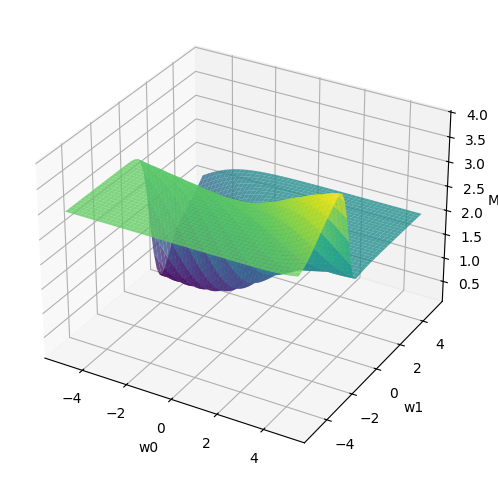

In [ ]:
# Visualization of the MSE function change
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Lambdify to convert sympy expr -> numpy function
mse_func = sp.lambdify((w0, w1), mse_full, "numpy")

# Grid of values
w0_vals = np.linspace(-5, 5, 50)
w1_vals = np.linspace(-5, 5, 50)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
Z = mse_func(W0, W1)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.8)

ax.set_xlabel("w0")
ax.set_ylabel("w1")
ax.set_zlabel("MSE")
plt.show()

**Because the function graph is non-convex, it is really hard to teach machine learning model with such loss. That is why it is recommended to use other types of loss function like cross-entropy or log loss when using Logistic Regression algorithms**

#### Let's see if the log loss makes our function convex

In [ ]:
# Implementation of log-loss function
log_loss = -(y_true * sp.log(y) + (1 - y_true) * sp.log(1 - y))
log_loss

-y_true*log(1/(2.71828182845905**(-w0 - w1*x) + 1)) - (1 - y_true)*log(1 - 1/(2.71828182845905**(-w0 - w1*x) + 1))

In [ ]:
# Calculating log loss in my dataset
log_loss_full = log_loss.subs({x : 1.2, y_true : 0}) + log_loss.subs({x : 2.5, y_true : 0}) + log_loss.subs({x : 3.8, y_true : 1}) + log_loss.subs({x : 4.5, y_true : 1}) + log_loss.subs({x : 5.9, y_true : 1})
log_loss_full

-log(1 - 1/(2.71828182845905**(-w0 - 2.5*w1) + 1)) - log(1 - 1/(2.71828182845905**(-w0 - 1.2*w1) + 1)) - log(1/(2.71828182845905**(-w0 - 5.9*w1) + 1)) - log(1/(2.71828182845905**(-w0 - 4.5*w1) + 1)) - log(1/(2.71828182845905**(-w0 - 3.8*w1) + 1))

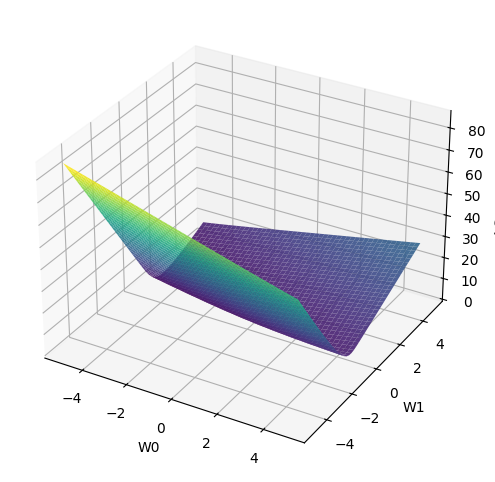

In [ ]:
# Visualization of Log-Loss function
# Lambdifying function before graph of the function
log_loss_func = sp.lambdify((w0, w1), log_loss_full, "numpy")

Z = log_loss_func(W0, W1)

# Plot
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(W0, W1, Z, cmap = 'viridis', alpha = 0.9)

ax.set_xlabel("W0")
ax.set_ylabel("W1")
ax.set_zlabel("LOG LOSS")
plt.show()

**Stochastic gradient descent(SGD)**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Preparing dataset
df = pd.DataFrame({
    'Height': [150, 160, 170, 180, 190],
    'Weight': [50, 65, 70, 80, 100]
})

stc = StandardScaler()
df = pd.DataFrame(stc.fit_transform(df), columns = df.columns)

X = df['Height'].values
y = df['Weight'].values

df

,Height,Weight
0,-1.414214,-1.384437
1,-0.707107,-0.481543
2,0.000000,-0.180579
3,0.707107,0.421350
4,1.414214,1.625209


In [ ]:
# Initial parameters
w = 0.0
b = 0.0
lr = 0.01
epochs = 10000
rng = np.random.default_rng(42)
n = len(X)

# SGD loop
for epoch in range(epochs):
    idx = rng.permutation(n)  
    epoch_loss = 0.0
    for i in idx:
        xi = X[i]
        yi = y[i]
        yhat = w*xi + b
        err = yi - yhat

        # gradients for loss = 0.5*err^2
        dw = - xi * err
        db = - err

        w = w - lr * dw
        b = b - lr * db

        epoch_loss += err**2

    if (epoch+1) % 50 == 0 or epoch == 0:
        mse = epoch_loss / n
        print(f"Epoch {epoch+1:3d}  MSE={mse:.6f}  w={w:.6f}  b={b:.6f}")

Epoch   1  MSE=0.980996  w=0.048337  b=-0.000189
Epoch  50  MSE=0.049106  w=0.901455  b=0.000246
Epoch 100  MSE=0.042484  w=0.973061  b=0.000414
Epoch 150  MSE=0.042441  w=0.978800  b=0.000502
Epoch 200  MSE=0.042443  w=0.979561  b=0.000521
Epoch 250  MSE=0.042437  w=0.979589  b=0.000344
Epoch 300  MSE=0.042440  w=0.979453  b=0.000075
Epoch 350  MSE=0.042436  w=0.979085  b=0.000603
Epoch 400  MSE=0.042435  w=0.979044  b=0.000044
Epoch 450  MSE=0.042440  w=0.979282  b=0.000408
Epoch 500  MSE=0.042442  w=0.979411  b=0.000531
Epoch 550  MSE=0.042440  w=0.979256  b=0.000314
Epoch 600  MSE=0.042431  w=0.979337  b=0.000021
Epoch 650  MSE=0.042436  w=0.979373  b=0.000452
Epoch 700  MSE=0.042435  w=0.979385  b=0.000404
Epoch 750  MSE=0.042432  w=0.979475  b=0.000692
Epoch 800  MSE=0.042431  w=0.979678  b=0.000648
Epoch 850  MSE=0.042434  w=0.979344  b=0.000440
Epoch 900  MSE=0.042434  w=0.978890  b=0.000237
Epoch 950  MSE=0.042443  w=0.979579  b=0.000698
Epoch 1000  MSE=0.042440  w=0.979424  b

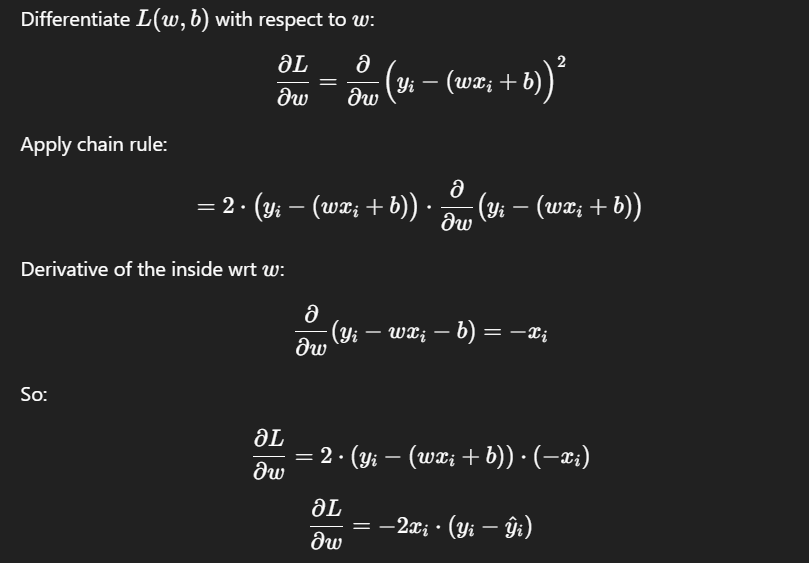

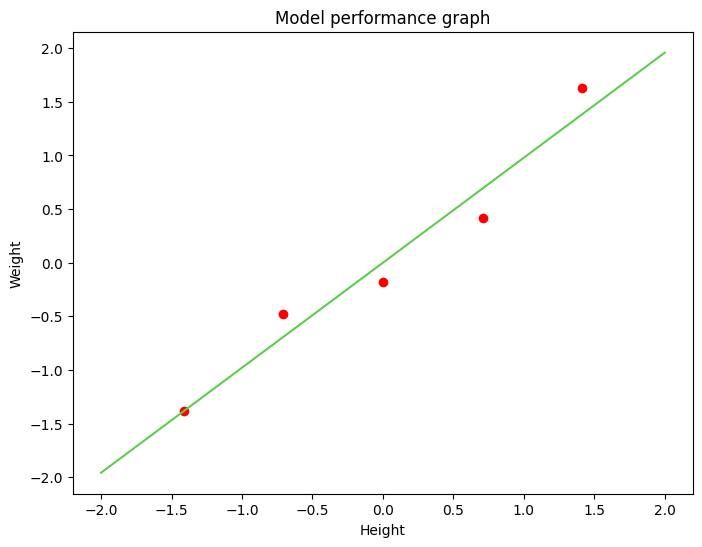

In [ ]:
# Plotting graph of the function and the data
x = np.linspace(-2, 2, 100)
lr_function = w * x + b 

# Graph of the function
plt.figure(figsize = (8, 6))
plt.scatter(df['Height'], df['Weight'], c = 'red')
plt.plot(x, lr_function, color = "#5CCE4D")
plt.title(label = "Model performance graph")
plt.xlabel(xlabel = "Height")
plt.ylabel(ylabel = "Weight")
plt.show()

In [ ]:
# Check what happens when Standart scaler is not used in the dataset before training


**Tasks :**

In this practical task, you are going to work with blood pressure data of humans. Based on some indicators of the human blood pressure, you are going to predict whether the human is sick or not.

Purpose of the practical work is to make you able to make linear models with gradient descent without using any libraries.

Our dataset contains following information :

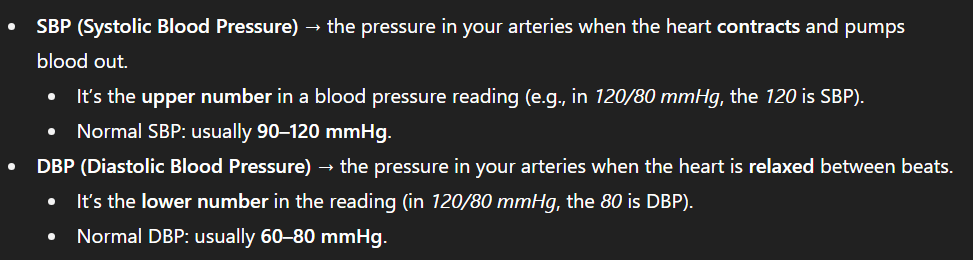

But this indicators are normalized and scaled into smaller measurements.

Target - whether or not human is sick(1 -> sick, 0 -> healthy)

In [ ]:
# Importing necessary libraries and loading required dataframes
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

df = pd.read_csv("./datasets/BloodPressure.csv")

df.head()

,SBP,DBP,target
0,0.943625,-0.679783,1
1,-0.868018,-0.253922,0
2,-1.767471,-0.999924,0
3,0.572276,0.394579,1
4,-1.436026,-1.307645,0


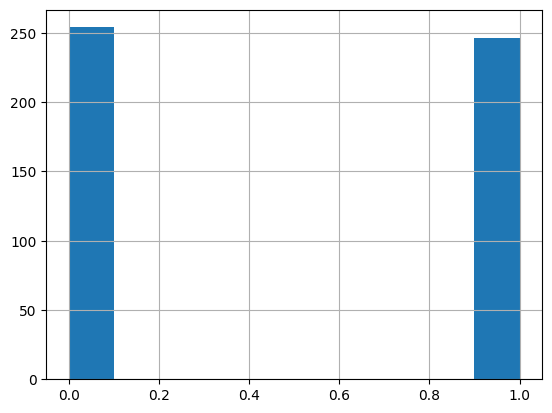

In [ ]:
# Checking if the data is balanced
df['target'].hist()
plt.show()

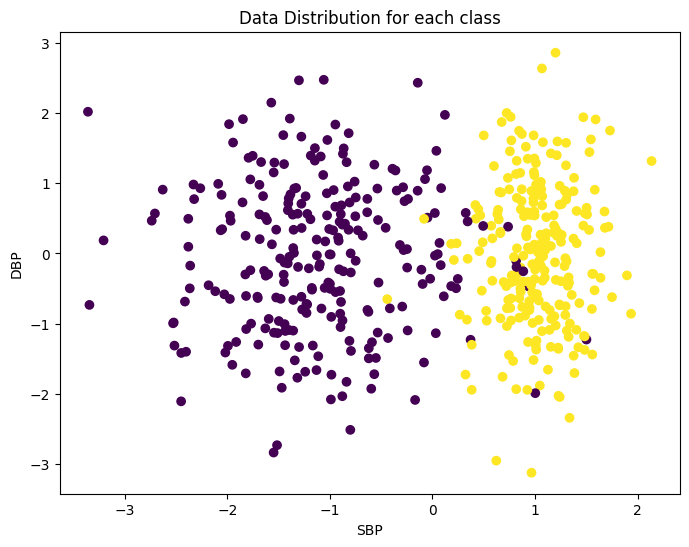

In [ ]:
# Checking the data distribution using scatter plot
plt.figure(figsize = (8, 6))
plt.scatter(x = df['SBP'], y = df['DBP'], c = df['target'])
plt.title(label = 'Data Distribution for each class')
plt.xlabel(xlabel = 'SBP')
plt.ylabel(ylabel = 'DBP')
plt.show()

In [ ]:
X = df[['SBP','DBP']]
y = df['target']

Because the task is classification problem and the data is balanced enough, we are going to use accuracy as loss function and Stochastic Gradient Descent for optimization. The question is, can we actually use accuracy metric as loss function to the gradient descent algorithm.

In [ ]:
# Your answer here


Write function for the calculation of sigmoid function over here(For logistic regression) :

In [ ]:
def sigmoid(x):
    # Your code goes here
    y = 1 / (1 + np.exp(-x))
    return y

Because we are going to use Log-Loss(or cross-entropy) as loss function in our machine learning model, we have to make function to calculate this automatically over the process of training. Make this function the in the cell below :

In [ ]:
np.hstack((np.ones((X.shape[0], 1)), X))

array([[ 1.        ,  0.94362459, -0.67978299],
       [ 1.        , -0.86801821, -0.2539218 ],
       [ 1.        , -1.76747111, -0.99992369],
       ...,
       [ 1.        ,  0.97582221, -0.99135789],
       [ 1.        ,  0.96005163,  0.58374514],
       [ 1.        , -1.52281126,  0.33935343]])

In [ ]:
np.random.rand(X.shape[1])

array([0.3595079 , 0.43703195])

In [ ]:
def compute_cost(X, y, theta) :
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-5
    cost = (1/m)*(((-y).T @ np.log(h + epsilon))-((1-y).T @ np.log(1-h + epsilon)))
    return cost

**So we have everything we need, but for the optimization problem, we have to make function which calculates cost and changed parameters every single iteration.**

In [ ]:
random.sample(range(X.shape[0]),1)

[52]

In [ ]:
def stochastic_grad(X, y, params, learning_rate=0.01, iterations=1000):
    X = np.asarray(X)              
    y = np.asarray(y).ravel()      
    params = np.asarray(params).ravel()  

    m = X.shape[0]
    cost_track = np.zeros(iterations)

    for it in range(iterations):
        idx = random.randrange(m)        
        x_i = X[idx]                    
        y_i = y[idx]                     
        h_i = sigmoid(np.dot(x_i, params)) 
        params = params - learning_rate * (x_i * (h_i - y_i))
        cost_track[it] = compute_cost(X, y, params)

    return cost_track, params

We have made every function needed to train machine learning model, after this, we have to make function for prediction.

In [ ]:
def predict(X, params):
    X = np.hstack((np.ones((X.shape[0], 1)), X))

    return np.round(sigmoid(X @ params))

Create first state of your model with required parameters.

In [ ]:
# Creating first state of the model
params = np.zeros((X.shape[1],1))

iterations = 1500
learning_rate = 0.03

**Teach model with stochastic gradient descent and see how cost function change over the time**

Optimal parameters are : 
 [3.17002497 0.02262062] 



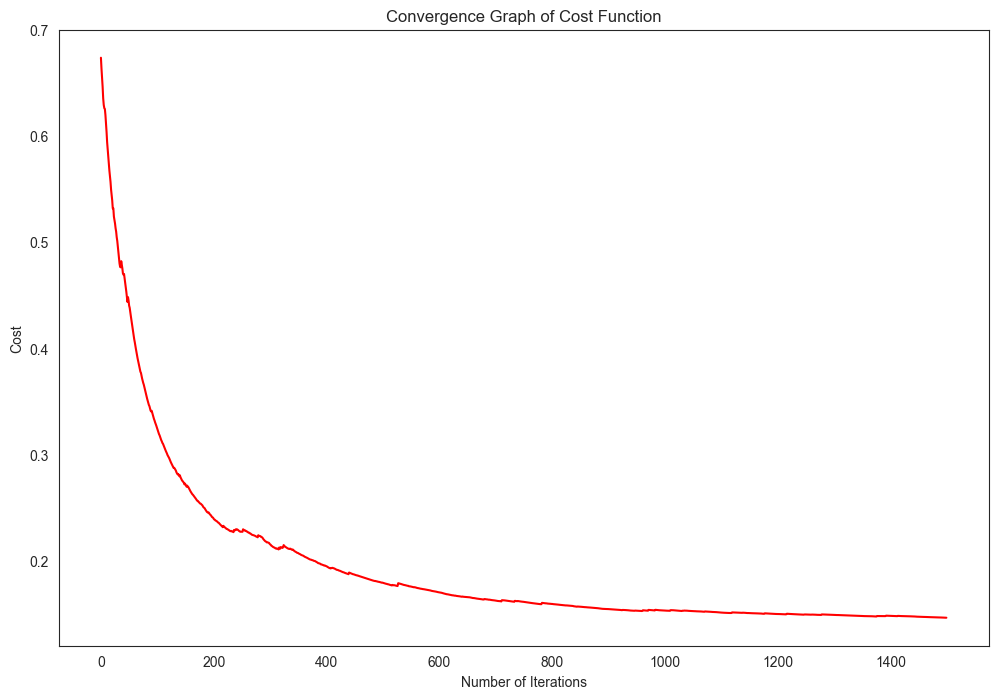

In [ ]:
# Model training
cost_history, params_optimal = stochastic_grad(X, y, params, learning_rate, iterations)

print("Optimal parameters are : \n", params_optimal, "\n")

plt.figure(figsize = (12, 8))
sns.set_style('white')
plt.plot(range(len(cost_history)), cost_history, 'r')
plt.title("Convergence Graph of Cost Function")
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.show()

In [ ]:
# Implementation using sklearn
# Make model using Logistic regression in sklearn and calculate the accuracy metric for the problem above
